In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw = pd.read_csv('insurance_data.csv')

df = raw.copy()
df = df[df['Issue_Year'] <= 2025]
df = df[df['Face_Amount'] > 0]
df = df[df['Annual_Premium'] > 0]
df = df[df['Term_Length'].notna()]

current_year = 2025

In [3]:
def Revenue(row):
    """
    we calculate the total revenue, which is the premium collected - 
    """
    issue = row['Issue_Year']
    premium = row['Annual_Premium']
    face = row['Face_Amount']
    status = row['Policy_Status']
    term_end = issue + int(row['Term_Length'])

    if status == 'Death' and pd.notna(row['Death_Year']):
        end_year = int(row['Death_Year'])
    elif status == 'Lapsed' and pd.notna(row['Lapse_Year']):
        end_year = int(row['Lapse_Year'])
    elif status == 'Lapsed' and pd.isna(row['Lapse_Year']):
        end_year = min(current_year, (issue + term_end) // 2)
    else:
        end_year = min(current_year, term_end)

    years_paid = max(0, end_year - issue)
    total_premium = premium * years_paid
    death_payout = face if status == 'Death' else 0

    return pd.Series({
        'years_paid': years_paid,
        'end_year': end_year,
        'term_end': term_end,
        'premium': total_premium,
        'death_payout': death_payout,
        'net_income': total_premium - death_payout,
    })

In [4]:
results = df.apply(Revenue, axis=1)
df = pd.concat([df, results], axis=1)

In [5]:
total_death_payout = df['death_payout'].sum()
total_premium = df['premium'].sum()
total_net = df['net_income'].sum()

In [6]:
print(f"Total premiums collected:  ${total_premium}")
print(f"Total death payouts:         ${total_death_payout}")
print(f"Net Income:      ${total_net}")

Total premiums collected:  $1703651.0499999998
Total death payouts:         $9645000.0
Net Income:      $-7941348.949999999


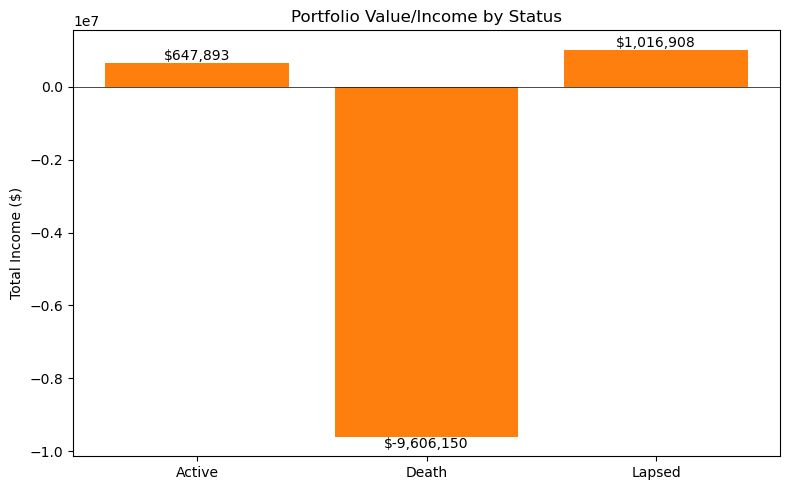

In [10]:
plt.figure(figsize=(8, 5))
group_totals = df.groupby('Policy_Status')['net_income'].sum()

plt.bar(group_totals.index, group_totals.values)
bars = plt.bar(group_totals.index, group_totals.values)

plt.bar_label(bars, fmt='${:,.0f}')
plt.ylabel('Total Income ($)')
plt.title('Portfolio Value/Income by Status')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

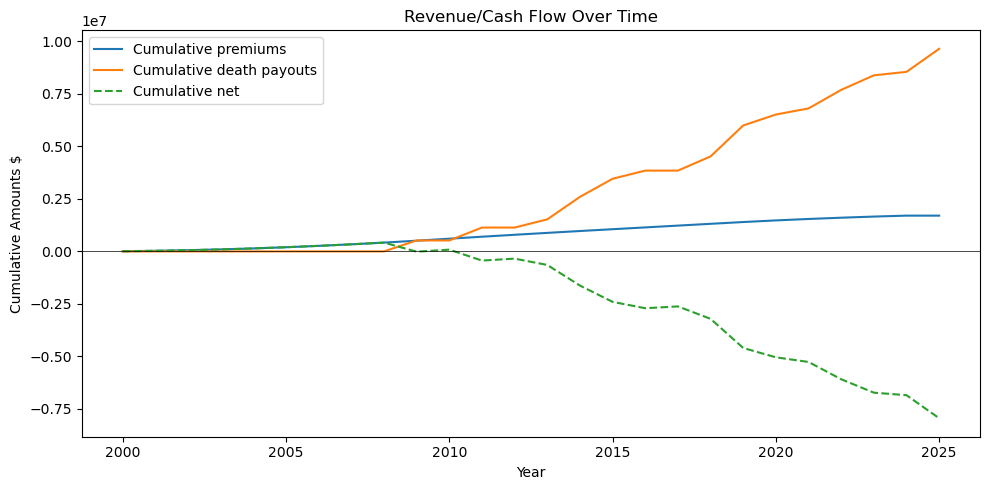

In [8]:
years = list(range(int(df['Issue_Year'].min()), 2026))
yearly_prem = []
yearly_death = []

for yr in years:
    paying = df[(df['Issue_Year'] <= yr) & (df['end_year'] > yr)]
    yearly_prem.append(paying['Annual_Premium'].sum())
    died = df[(df['Policy_Status'] == 'Death') & (df['Death_Year'] == yr)]
    yearly_death.append(died['Face_Amount'].sum())

cum_prem = np.cumsum(yearly_prem)
cum_death = np.cumsum(yearly_death)
cum_net = cum_prem - cum_death

plt.figure(figsize=(10, 5))
plt.plot(years, cum_prem, label='Cumulative premiums')
plt.plot(years, cum_death, label='Cumulative death payouts')
plt.plot(years, cum_net, linestyle='--', label='Cumulative net')

plt.axhline(y=0, color='black', linewidth=0.5)
plt.xlabel('Year')
plt.ylabel('Cumulative Amounts $')
plt.title('Revenue/Cash Flow Over Time')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/7f/dxbs_v_n57d1g7687xghcbzc0000gn/T/ipykernel_79434/569682621.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


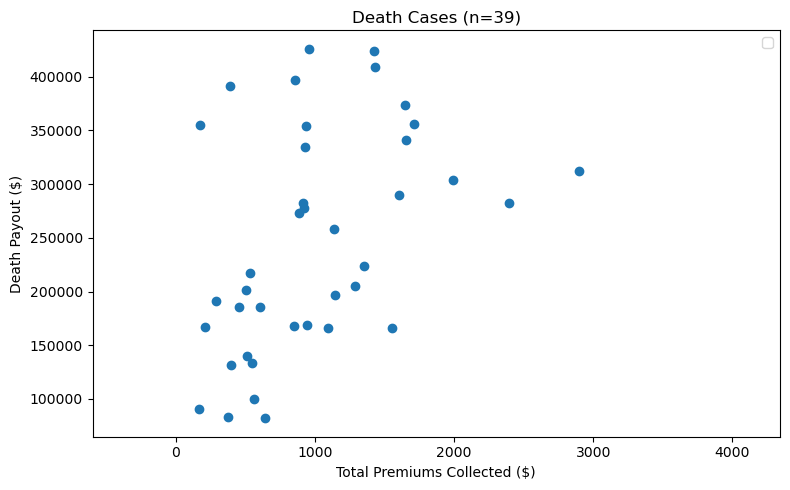

In [12]:
deaths = df[df['Policy_Status'] == 'Death']

plt.figure(figsize=(8, 5))
plt.scatter(deaths['premium'], deaths['death_payout'])
max_val = max(deaths['premium'].max(), deaths['death_payout'].max()) * 1.1

plt.xlim(-600, deaths['premium'].max() * 1.5)

plt.xlabel('Total Premiums Collected ($)')
plt.ylabel('Death Payout ($)')
plt.title(f'Death Cases (n={len(deaths)})')
plt.legend()
plt.tight_layout()
plt.show()